Brianna Lannerd
08/26/2026
Lab 1 - Projectile Motion Solver
Disclaimer: Certain functions, loops, and variables were copied from the reading materials given for the module. AI was also used to assist with creating and trouble shooting this code.

In [646]:
#Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt



Part A: One Dimensional Free Fall. This code contains a function meant to simulate free fall when drag is considered negligible. The code uses acceleration due to gravity and a given initial height to calculate different kinematic information regarding the free fall such as position, velocity, and time. 

In [647]:
#Section 1 of part A
def simulate_freefall (h,dt,g=9.81):
    state = np.array([h,0])
    y=h
    vy=0
    t=0
    ys, ts, vys = [y],[0],[vy]
    while y >= 0:
        vy = vy - g * dt
        y = y+ vy * dt
        t += dt
        ys.append(y)
        vys.append(vy)
        ts.append(t)
    return np.array(ts), np.array(ys), np.array(vys)

#Section 2 of part A
h=100
dt=0.1
g=9.81
ts, ys, vys = simulate_freefall(h,dt,g)


The function above is the free fall simulation, as well as the initialization of variables and the calling of the function so that it runs and stores the values for the variables in their respective arrays. 

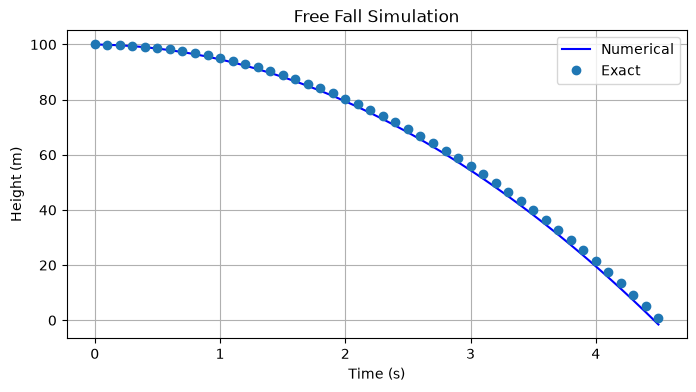

In [648]:
#Section 3 of part A
tf = np.sqrt(2*h/g)
v_exact = -g * tf
y_exact = h - 0.5 * g * ts**2
plt.figure(figsize=(8,4))
plt.plot(ts,ys, '-b', label='Numerical')
plt.plot(ts,y_exact, 'o', label='Exact')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Free Fall Simulation')
plt.grid(True)
plt.legend()
plt.show()

The code above plots y vs t which in this case is the time the object has been in free fall as the independent variable and the position or height of the object as the dependent variable. The line represents the exact solutions of the position as a function of time. Each individual dot represents the result of the simulation of the position as a function of t at that specific timestep. The graph looks as expected since in free fall, the object falls downwards towards height=o at a constant acceleration.

In [649]:
#Section 4 of part A
print("Numerical final time =", ts[-1], "s")
print("Numerical final velocity =", vys[-1], "m/s")

# Section 5 of part A (question a)
print("Exact final time =", tf, "s")
print("Exact final velocity =", v_exact, "m/s")

print("Percent difference in final time =", abs(100*(ts[-1] - tf)/tf), "%")
print("Percent difference in final velocity =",abs(100*(vys[-1] - v_exact)/v_exact), "%")

Numerical final time = 4.5 s
Numerical final velocity = -44.145000000000046 m/s
Exact final time = 4.515236409857309 s
Exact final velocity = -44.294469180700204 m/s
Percent difference in final time = 0.3374443434245404 %
Percent difference in final velocity = 0.33744434342444896 %


Question a) The numerical landing time is 4.5 seconds and the exact landing time is 4.515236409857309 seconds. The percentage error is 0.3374443434245404 %. 
The equations above are the exact solution equations. The equations come from the assignment pdf. The exact final time is slightly later than the simulation final time which could be due to rounding in the code. The exact final velocity is slightly slower than the exact final velocity. The percent difference between both the final time and exact final time as well as the the percent difference between the final velocity and exact final velocity are very small.

In [650]:
# Section 5 of part A (question b)

# Percent error for dt=1.0
h=100
dt=1.0
g=9.81
ts, ys, vys = simulate_freefall(h,dt,g)
y_exact = h - 0.5 * g * ts**2
tf=np.sqrt(2*h/g)
v_exact = -g * tf
print("Percent difference in final time (dt=1.0 s) =", abs(100*(ts[-1] - tf)/tf), "%")

print("Percent difference in final velocity (dt=1.0 s) =", abs(100*(vys[-1] - v_exact)/v_exact), "%")

#Percent error for dt=0.1
h=100
dt=0.1
g=9.81
ts, ys, vys = simulate_freefall(h,dt,g)

y_exact = h - 0.5 * g * ts**2
tf=np.sqrt(2*h/g)
v_exact = -g * tf

print("Percent difference in final time (dt=0.1 s) =", abs(100*(ts[-1] - tf)/tf), "%")
print("Percent difference in final velocity (dt=0.1 s) =", abs(100*(vys[-1] - v_exact)/v_exact), "%")

#Percent error for dt=0.01
h=100
dt=0.01
g=9.81
ts, ys, vys = simulate_freefall(h,dt,g)

y_exact = h - 0.5 * g * ts**2
tf=np.sqrt(2*h/g)
v_exact = -g * tf

print("Percent difference in final time (dt=0.01 s) =", abs(100*(ts[-1] - tf)/tf), "%")
print("Percent difference in final velocity (dt=0.01 s) =", abs(100*(vys[-1] - v_exact)/v_exact), "%")

Percent difference in final time (dt=1.0 s) = 10.736172951750511 %
Percent difference in final velocity (dt=1.0 s) = 10.736172951750506 %
Percent difference in final time (dt=0.1 s) = 0.3374443434245404 %
Percent difference in final velocity (dt=0.1 s) = 0.33744434342444896 %
Percent difference in final time (dt=0.01 s) = 0.1055003483813113 %
Percent difference in final velocity (dt=0.01 s) = 0.1055003483827078 %


The error decreases as the time step gets smaller.

Part B: Two Dimensional Projectile. The code below simulates a 2D projectile which means it has velocity in both the x and y direction. The state variable has a length of 4. Air resistance is still negligible which means there is only acceleration in the y direction which is due to gravity.

In [651]:
#Section 1 of part B
def simulate_projectile_2d (v0, theta_deg,dt,g):
    x=0
    y=0
    vx=v0*np.cos(np.radians(theta_deg))
    vy=v0*np.sin(np.radians(theta_deg))
    t=0

    #Storage Lists for plotting
    ts, xs, ys, vxs, vys = [0], [0], [0], [v0*np.cos(np.radians(theta_deg))], [v0*np.sin(np.radians(theta_deg))]

    #Loop until projectile hits the ground
        
    while y >= 0:
        ax=0.0
        ay=-g

        #Update Veloctiy
        vy = vy + ay * dt
        vx= vx+ ax*dt
        #Update Position
        x = x + vx * dt
        y = y+ vy * dt
            
        t += dt
        xs.append(x)
        ys.append(y)
        vxs.append(vx)
        vys.append(vy)
        ts.append(t)
    return np.array(ts),np.array(xs), np.array(ys), np.array(vxs), np.array(vys)

#Section 2 of part B
v0=30
theta_deg=45
dt = 0.01
g=9.81
ts, xs, ys, vxs, vys = simulate_projectile_2d(v0, theta_deg, dt, g)



The function above simulates a 2D projectile taking the inputs of intial velocity, launch angle, timestep, and acceleration due to gravity. It stores the values at each timestep in its respective array whilst the projectile is in the air. The simulation is then initialized with the velocity at 30 m/s, the launch angle at 25 degrees, acceleration due to gravity at 9.81 m/s^2 and a timestep of 0.01.

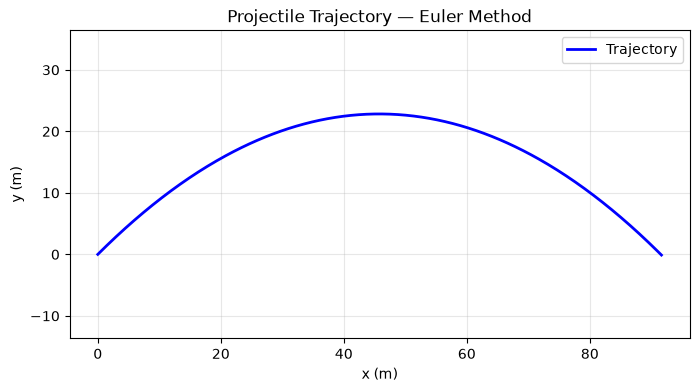

In [652]:
#Section 3 of part B
plt.figure(figsize=(8, 4))
plt.plot(xs, ys, 'b-', linewidth=2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Trajectory — Euler Method')
plt.grid(True, alpha=0.3)
plt.legend(['Trajectory'])
plt.axis('equal')
plt.show()


The graph above shows both the y and x position of the ball at any time whilst the ball is in the air. The line is solid because it is the exact trajectory. The graph is a parabola facing downwards which makes sense because the second derivative (acceleration) is a negative value and a constant. The graph also never goes below y=0 which is logical because the simulation bounds have the ground at y=0. 

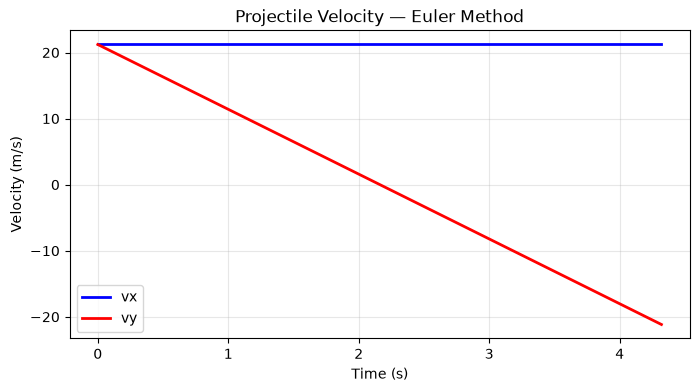

In [653]:
#Section 4 of part B
plt.figure(figsize=(8, 4))
plt.plot(ts, vxs, 'b-', label='vx', linewidth=2)
plt.plot(ts, vys, 'r-', label='vy', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Projectile Velocity — Euler Method')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Question a) The velocity in the x-direction is a horizontal line which is what I expected based on theory, because during projectile motion velocity in the x direction stays constant when drag is considered negligible. The velocity in the y-direction is a negatively sloped and negative which makes since because when drag is assumed negligible, the only force acting on the projectile in the y direction is gravity. The acceleration due to gravity is constant, so when the ball is moving upwards towards its peak, gravity is acting in the direction opposite of the motion so the velocity decreases. At the exact moment the ball changes direction, the velocity is zero which explains why the line crosses the x axis. Then the velocity increased on the way down because gravity is acting in the direction of the motion. 

In [654]:
#Section 5 of part B

theta_rad = np.radians(theta_deg)
# Caclulating exact values for range, max height, and flight time
range1 = v0**2 * np.sin(2*np.radians(theta_deg)) / g
max_height = (v0**2 * np.sin(np.radians(theta_deg))**2) / (2*g)
flight_time = 2*v0*np.sin(np.radians(theta_deg))/g

print("Exact Values:")
print("Range =", range1, "m")
print("Max Height =", max_height, "m")
print("Flight Time =", flight_time, "s")

#Getting numerical values for range, max height, and flight time
numerical_range = xs[-1]
numerical_max_height = max(ys)
numerical_flight_time = ts[-1]
print("Numerical Values:")
print("Range =", numerical_range, "m")
print("Max Height =", numerical_max_height, "m")
print("Flight Time =", numerical_flight_time, "s")

#Calculating percent error for range, max height, and flight time
range_error = abs((range1 - numerical_range) / range1) * 100
height_error = abs((max_height - numerical_max_height) / max_height) * 100
time_error = abs((flight_time - numerical_flight_time) / flight_time) * 100
print(f"range error =", range_error, "%")
print(f"height error =", height_error, "%")
print(f"time error =", time_error, "%")


Exact Values:
Range = 91.74311926605505 m
Max Height = 22.935779816513765 m
Flight Time = 4.324812117348914 s
Numerical Values:
Range = 91.64103884177646 m
Max Height = 22.829803420888364 m
Flight Time = 4.319999999999952 s
range error = 0.11126766246365534 %
height error = 0.46205708492674813 %
time error = 0.11126766246464645 %


The exact values are greater than the numerical values. The percentage errors show that the numerical values and exact values are very similar.

The code below runs the simulation for launch angles from 10 degrees to 80 degrees in steps of 5. 

In [655]:
#Section 6 of part B
angles = np.arange(10, 85, 5)
ranges = []
for angle in angles:
    ts, xs, ys, vxs, vys = simulate_projectile_2d(v0, angle, dt, g)

    projectile_range = xs[-1]
    ranges.append(projectile_range)

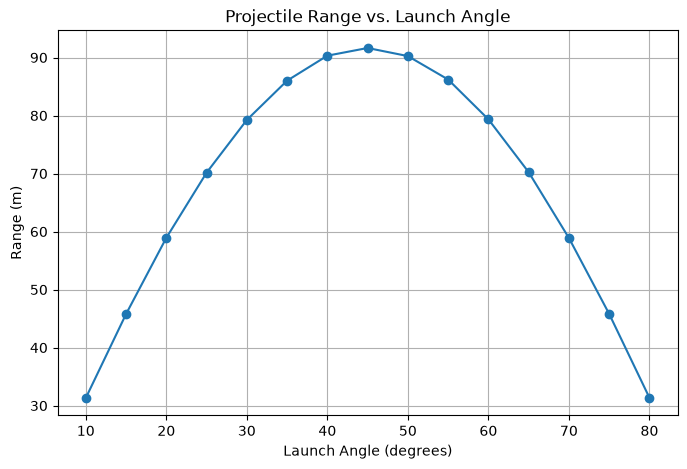

In [656]:
plt.figure(figsize=(8, 5))

plt.plot(angles, ranges, marker="o")

plt.xlabel("Launch Angle (degrees)")
plt.ylabel("Range (m)")
plt.title("Projectile Range vs. Launch Angle")
plt.grid()

plt.show()

Question b) The plot above shows the range vs launch angle. This matches theory because in physics, when air resistance is negligible, the maximum range of a projectile should occur when the angle equals 45 degrees. This is not just driven by experimental data but by calculations. When there is no air resistance, the only part of the range equation that changes with the angle is sin(2*theta). Sine can never be greater than 1 which equals sin (90 degrees), so theta=45 makes 2*theta=90 which maximizers sin(2*theta).

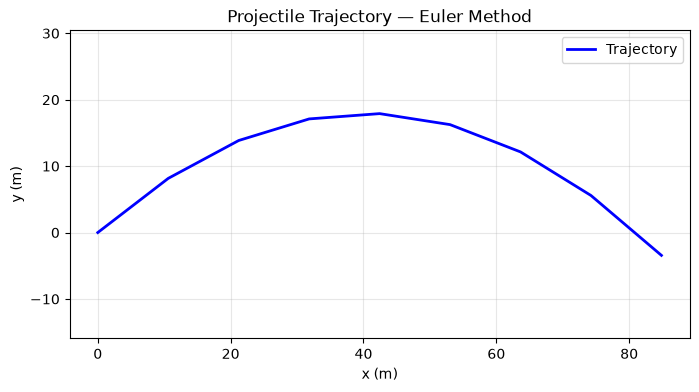

In [657]:
#Changing timestep to 0.5 seconds
v0=30
theta_deg=45
dt = 0.5
g=9.81
ts, xs, ys, vxs, vys = simulate_projectile_2d(v0, theta_deg, dt, g)
plt.figure(figsize=(8, 4))
plt.plot(xs, ys, 'b-', linewidth=2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Trajectory — Euler Method')
plt.grid(True, alpha=0.3)
plt.legend(['Trajectory'])
plt.axis('equal')
plt.show()

Question c) When you change the timestep to 0.5, you decrease the amount of times at which the x and y positions are calculated which makes the graph more of an approximation. This increases percentage errors for both x and y and results in a graph that loses the smooth curve you expect of a projectile motion graph based on theory. 

Part C: Projectile with Air Resistance. This simulation is still 2d but it incorporates air resistance as a force that acts on the projectile. 

In [658]:
#Section 1 of part C
def simulate_projectile_drag(v0, theta_deg, dt, g, b_over_m):
    x = 0
    y = 0

    vx = v0 * np.cos(np.radians(theta_deg))
    vy = v0 * np.sin(np.radians(theta_deg))

    t = 0

    ts = [t]
    xs = [x]
    ys = [y]
    vxs = [vx]
    vys = [vy]

    while y >= 0:

        speed = np.sqrt(vx**2 + vy**2)

        # Acceleration with drag
        ax = -(b_over_m) * speed * vx
        ay = -g - (b_over_m) * speed * vy

        # Update Variables
        x = x + vx * dt
        y = y + vy * dt

        vx = vx + ax * dt
        vy = vy + ay * dt

        t += dt

        ts.append(t)
        xs.append(x)
        ys.append(y)
        vxs.append(vx)
        vys.append(vy)

    return np.array(ts), np.array(xs), np.array(ys), np.array(vxs), np.array(vys)

In [659]:
#Section 2 of part C
v0 = 45
theta_deg = 40
dt = 0.01
g = 9.81
b_over_m = 0.0046

# With drag
ts_drag, xs_drag, ys_drag, vxs_drag, vys_drag = simulate_projectile_drag(
    v0, theta_deg, dt, g, b_over_m
)

# Without drag
ts_no_drag, xs_no_drag, ys_no_drag, vxs_no_drag, vys_no_drag = simulate_projectile_2d(
    v0, theta_deg, dt, g
)

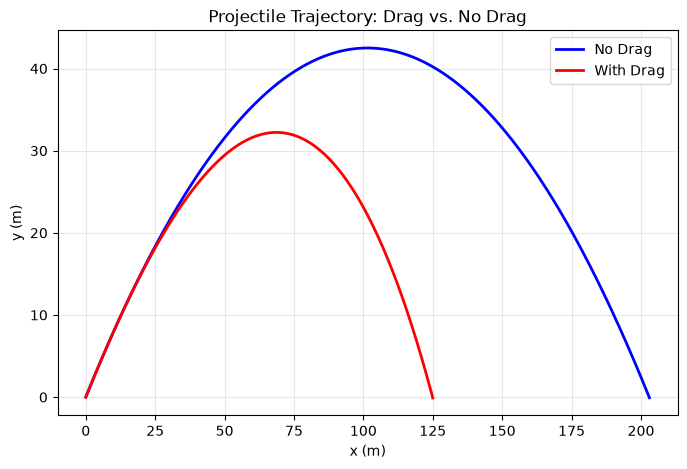

In [660]:
#Section 3 of part C
#Plotting drag and no drag trajectories
plt.figure(figsize=(8, 5))
plt.plot(xs_no_drag, ys_no_drag, 'b-', label='No Drag', linewidth=2)
plt.plot(xs_drag, ys_drag, 'r-', label='With Drag', linewidth=2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Trajectory: Drag vs. No Drag')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The graph above shows the projectile's trajectory when there is drag and when there is no drag. Both trajectories show a parabola, although the no drag parabola is perfectly symmetric. This is expected because drag changes the flight time and acceleration on the ball and acts always opposite of the balls movement whereas gravity acts against the ball on the way up and in the same direction on the way down. The range and height of the projectile experiencing drag is less than no drag which is expected since the projectile has a second force acting upon it, and in this case against it. 

In [661]:
#Section 4 of part C
# No-drag values
range_no_drag = xs_no_drag[-1]
max_height_no_drag = max(ys_no_drag)
print("No Drag:")
print("Range =", range_no_drag, "m")
print("Max Height =", max_height_no_drag, "m")

# Drag values
range_drag = xs_drag[-1]
max_height_drag = max(ys_drag)
print("With Drag:")
print("Range =", range_drag, "m")
print("Max Height =", max_height_drag, "m")

# Percent reduction in range
percent_reduction = ((range_no_drag - range_drag) / range_no_drag) * 100
print("\nPercent reduction in range =", percent_reduction, "%")

No Drag:
Range = 203.04007964868376 m
Max Height = 42.499735761529465 m
With Drag:
Range = 125.00251644204612 m
Max Height = 32.22441485305721 m

Percent reduction in range = 38.43456097025991 %


The drag causes a range reduction of approximately 38.4%. 

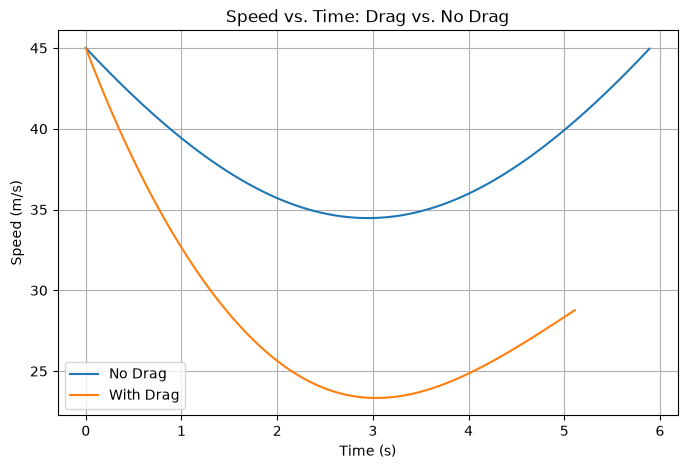

In [662]:
#Section 5 of part C
#Calculating speed for both cases and plotting them

speed_no_drag = np.sqrt(vxs_no_drag**2 + vys_no_drag**2)
speed_drag = np.sqrt(vxs_drag**2 + vys_drag**2)
plt.figure(figsize=(8, 5))
plt.plot(ts_no_drag, speed_no_drag, label='No Drag')
plt.plot(ts_drag, speed_drag, label='With Drag')
plt.xlabel('Time (s)')
plt.ylabel('Speed (m/s)')
plt.title('Speed vs. Time: Drag vs. No Drag')
plt.legend()
plt.grid(True)
plt.show()

The code below runs the simulation from the launch angles from 10 to 80 degrees in increments of 5 with the initial paramters: initial velocity= 45 m/s, the time step equals 0.01, acceleration due to gravity is 9.81 m/s^2, and the drag coefficient is 0.0046

In [663]:
#SEction 6 of part C
#Initialize parameters
v0 = 45
dt = 0.01
g = 9.81
b_over_m = 0.0046

#Launch angles from 10 to 80 degrees in increments of 5 degrees
angles = np.arange(10, 85, 5)

#Store ranges
ranges_no_drag = []
ranges_drag = []

for angle in angles:

    # No-drag 
    ts, xs, ys, vxs, vys = simulate_projectile_2d(
        v0, angle, dt, g
    )
    ranges_no_drag.append(xs[-1])

    # Drag simulation
    ts_d, xs_d, ys_d, vxs_d, vys_d = simulate_projectile_drag(
        v0, angle, dt, g, b_over_m
    )
    ranges_drag.append(xs_d[-1])

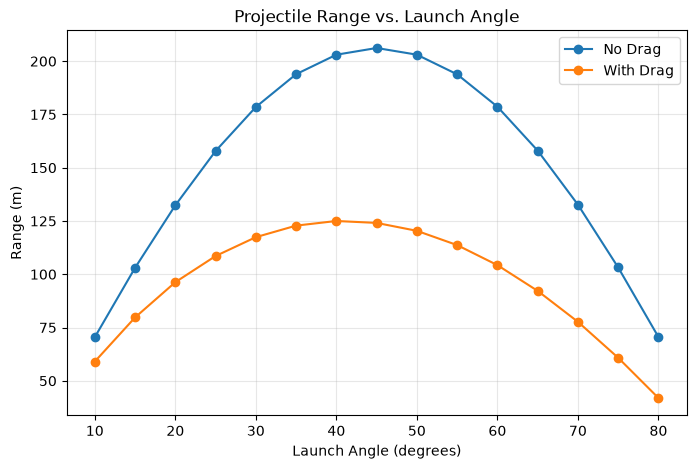

In [664]:
#Plot projectile Range vs. Launch Angle for both cases
plt.figure(figsize=(8, 5))
plt.plot(angles, ranges_no_drag, 'o-', label='No Drag')
plt.plot(angles, ranges_drag, 'o-', label='With Drag')
plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Projectile Range vs. Launch Angle')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Questions a, b, c. Drag reduces range dramatically because it is a force that acts against the direction of the projectiles motion for the entire flight time. Drag also increases as velocity increases. This simulation did not show it but drag also changes based on the shape of the projectile. Drag is the largest when the projectile iinitially launched and is moving upwards because the projectile starts with its maximum speed at launch and terminal velocity doesn't allow acceleration to increase the velocity of the projectile pass a specific velocity that is less than the launch velocity.  With drag, the maximum launch angle is near 40 degrees, so it is not 45 degrees. When there is air resistance, the longer the ball is in the air, the more time that the force of drag can act upon it. A slighly smaller launch angle results in a shorter flight time, but still allows enough flight time for the ball to travel a sufficient amount. The graph also makes sense that the projectile can not travel as far when there is a drag acting against it. If the timestep is small enough, I think Euler's method can work well for this problem. When the timestep is larger however, there is a decent percent error. I would check by seeing how much you have to increase the timestep to get much lower percent errors. Then I would see if the computing power required to do that small of a time step is worth it by comparing it to other approximation methods they may be more efficient. 

In [665]:
angles = np.arange(1, 89, 0.1)

angles_no_drag = []
angles_drag = []

v0 = 45
g = 9.81
dt = 0.01
b_over_m = 0.0046

for angle in angles:

    # No drag
    ts, xs, ys, vxs, vys = simulate_projectile_2d(
        v0, angle, dt, g
    )

    for x, y in zip(xs, ys):
        if x >= 120:
            if y >= 3:
                angles_no_drag.append(angle)
            break


    # With drag
    ts_d, xs_d, ys_d, vxs_d, vys_d = simulate_projectile_drag(
        v0, angle, dt, g, b_over_m
    )

    for x, y in zip(xs_d, ys_d):
        if x >= 120:
            if y >= 3:
                angles_drag.append(angle)
            break

In [666]:
print("NO DRAG")
print("Minimum angle =", angles_no_drag[0], "degrees")
print("Maximum angle =", angles_no_drag[-1], "degrees")
print("\nWITH DRAG")
print("Minimum angle =", angles_drag[0], "degrees")
print("Maximum angle =", angles_drag[-1], "degrees")

NO DRAG
Minimum angle = 19.500000000000018 degrees
Maximum angle = 72.00000000000006 degrees

WITH DRAG
Minimum angle = 35.50000000000003 degrees
Maximum angle = 48.40000000000004 degrees


Without drag the range of angles that clear the fence are [19.5,72]. With drag, the range of angles that clear the fence is [35.5,48.4], so yes it's possible.

In [ ]:
minimum_speed = None
optimal_angle = None

# Search a reasonable range
speeds = np.arange(40, 50, 0.1)
angles = np.arange(30, 55, 0.1)

for v0_test in speeds:

    best_height = -np.inf
    best_angle = None

    for angle in angles:

        # Initial conditions
        x = 0
        y = 0

        vx = v0_test * np.cos(np.radians(angle))
        vy = v0_test * np.sin(np.radians(angle))

        # stop if it reaches fence or ground
        while y >= 0 and x < 120:

            velocity = np.sqrt(vx**2 + vy**2)

            ax = -(b_over_m) * velocity * vx
            ay = -g - (b_over_m) * velocity * vy

            x = x + vx * dt
            y = y + vy * dt

            vx = vx + ax * dt
            vy = vy + ay * dt

        # If it reached the fence, record its height there
        if x >= 120:

            if y > best_height:
                best_height = y
                best_angle = angle

    # First speed whose best angle clears the fence
    if best_height >= 3:
        minimum_speed = v0_test
        optimal_angle = best_angle
        break


print("Minimum speed =", minimum_speed, "m/s")
print("Optimal angle =", optimal_angle, "degrees")

Minimum speed = 44.30000000000006 m/s
Optimal angle = 41.90000000000017 degrees


An initial speed of 44.3 m/s with drag is needed to guarentee a home run at the optimal angle. 